# Plausible DFS audit graphs: construction, plotting, and audits

This notebook walks through the full pipeline on a small election —
Shellharbour Ward D 2024 (6 candidates, 2 seats, N = 11,600):

1. build a **plausible audit graph** by depth-first search at a fixed
   Margin of Insecurity (writeup §2.1–2.2),
2. plot it,
3. run a **mismatch-based audit** (§3.2), and
4. run a **Delta-method audit** (§3.3).

Every step finishes in seconds. For the batch-elimination (seeded)
construction used on large elections, see `victoria_v2.ipynb`.


In [1]:
# Make the repo root importable when the kernel cwd is notebooks/.
import os, sys

repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


## 1. Load a ballot profile

Profiles are stored in the Scottish-election csv format under `data/`
(see `data/README.md`). `load_numpy` returns the profile together with
the number of seats recorded in the file.


In [2]:
from src.election_graphs.numpy_profile import load_numpy

profile, m, *_ = load_numpy(
    os.path.join(repo_root, "data", "nsw_local", "city_of_shellharbour_ward_d_2024.csv")
)
print(f"C = {len(profile.candidates)} candidates, m = {m} seats, "
      f"N = {round(profile.total_ballot_wt)} ballots")


C = 6 candidates, m = 2 seats, N = 11600 ballots


## 2. Build the plausible graph

The constructor starts from the root (all candidates hopeful) and follows
every edge that could have been chosen by the true tabulation if the
tallies of its base vertex were shifted by less than the Margin of
Insecurity `MoI` — here the value from the results table, M = 1,933.
`add_natural_edges` guarantees the reported election path is present,
and `coherence_check` verifies that every terminal vertex seats the same
winner set, which is what makes the graph auditable.


In [3]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor

constructor = WIGMGraphConstructor(
    profile,
    m=m,
    MoI=1933,
    memory_lite=True,
    simultaneous=True,
)
constructor.build()
constructor.add_natural_edges()
constructor.assign_tightest_margins()
constructor.coherence_check()


Coherence check passed.
  terminal vertices: 177
  winner set: ['PETRESKI Rob', 'MURPHY Kane']


True

## 3. Plot it

Layers run left to right (one per tabulation round); vertices are
colour-coded by how many winners they have seated.


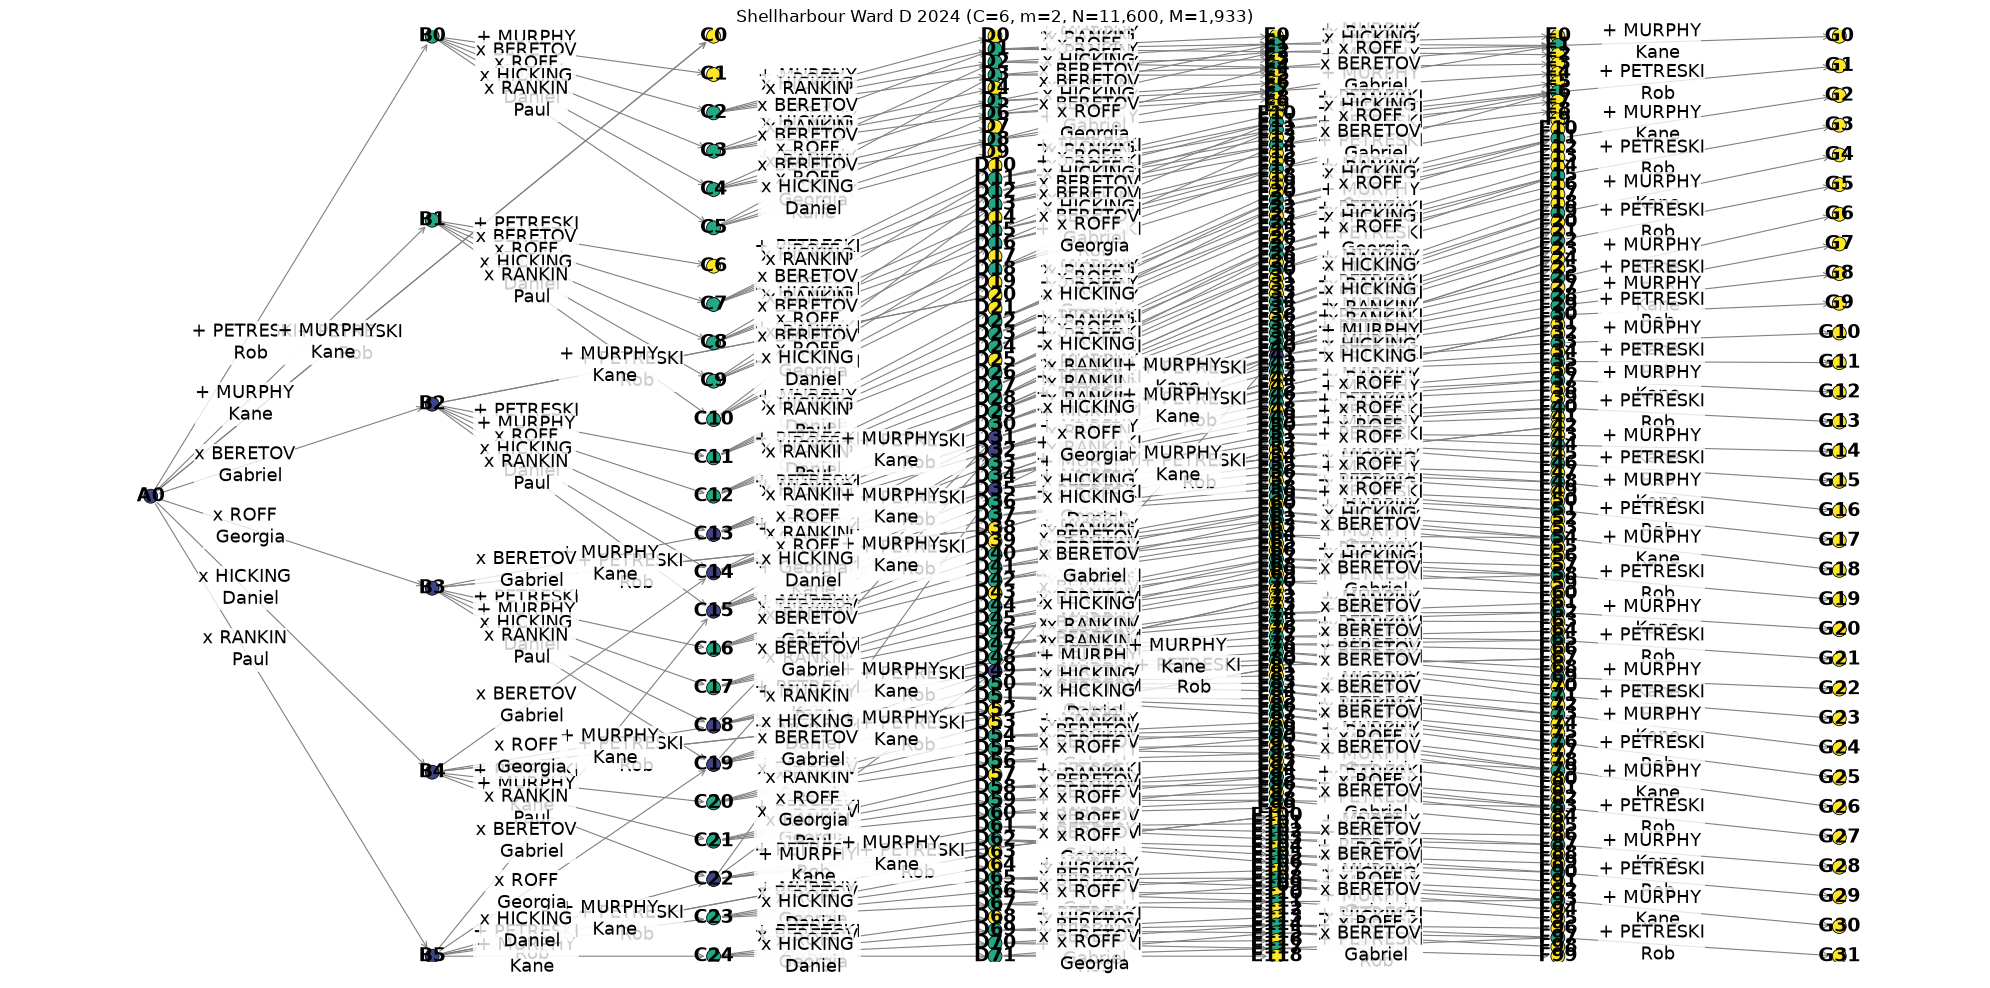

In [4]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 10),
    node_size=100,
    font_size=14,
    label_vertices=True,
    plot_horizontal=True,
    title="Shellharbour Ward D 2024 (C=6, m=2, N=11,600, M=1,933)",
)


## 4. Mismatch-based audit

The driver noises the CVRs (2% mismatches, the protocol of §3.4), builds
one COBRA noise-filter compiler per escape edge, and broadcasts sampled
ballot comparisons to all of them. The audit certifies when every
compiler has rejected its local null at risk level alpha = 5%; it fails
if the sample cap (here half the ballots) is reached first.


In [5]:
from src.test_processes.driver import GlobalAuditDriver

mismatch_driver = GlobalAuditDriver(
    constructor,
    noise_level=0.02,
    fractional_sample_size=0.5,
    seed=0,
    compiler_type="noise",
    simultaneous=True,
    alpha=0.05,
    print_diagnostics_every=25,
)
print(f"escape-edge compilers: {len(mismatch_driver.compilers)}")

certified = mismatch_driver.run(constructor.ballot_matrix)
print(f"certified: {certified} after {mismatch_driver.i} ballots")


escape-edge compilers: 408
Audit diagnostic after 25 samples: 201 compilers remain below threshold (207/408 certified).
  E51-E3: M=5.57283, escape=ELIMINATE 3:MURPHY Kane, margin=1616.1129811996425, kind=CobraNoiseFilterCompiler
  E56-E3: M=5.57948, escape=ELIMINATE 3:MURPHY Kane, margin=1617.1922043010763, kind=CobraNoiseFilterCompiler
  E102-E3: M=5.58692, escape=ELIMINATE 3:MURPHY Kane, margin=1618.3987410071943, kind=CobraNoiseFilterCompiler
  E109-E3: M=5.59362, escape=ELIMINATE 3:MURPHY Kane, margin=1619.4848784878495, kind=CobraNoiseFilterCompiler
  E47-E3: M=5.61197, escape=ELIMINATE 3:MURPHY Kane, margin=1622.450881612091, kind=CobraNoiseFilterCompiler
Audit certified all compilers. Final sample size: 44.
Last compilers to pass threshold:
  E90-E3: M=20.9126, escape=ELIMINATE 3:MURPHY Kane, margin=1624.7764323151996, kind=CobraNoiseFilterCompiler
  E102-E3: M=20.6549, escape=ELIMINATE 3:MURPHY Kane, margin=1618.3987410071943, kind=CobraNoiseFilterCompiler
  E109-E3: M=20.6985

## 5. Delta-method audit

The Delta driver instead draws a fixed-size sample and builds a Wald
confidence interval for each escape edge's critical margin, using the
symbolic margin machinery of `src/test_processes/symbolic_equations.py`.
The fraction below (0.4% of ballots) is the certifying sample size from
the results table; the audit passes iff every interval excludes the
escape.


In [6]:
from src.test_processes.delta_method import DeltaMethodAuditDriver

delta_driver = DeltaMethodAuditDriver(
    constructor,
    fractional_sample_size=0.004,
    noise_level=0.02,
    seed=0,
    alpha=0.05,
    verbose=True,
)
success = delta_driver.run()
print(f"certified: {success} with a sample of {delta_driver.sample_size} ballots")


Starting Delta-Method audit: 408 escape edges, 145 vertices, n=46, alpha=0.05, alpha_K=0.005, source=implicit sampler, seeded=False.
Layer 0 (1/5): 6 escape edges across 1 vertices.
  Vertex A0: 6 escape edges.
    [1/6; vertex 1/6; overall 1/408] A0-E0 PASS: escape=ELIMINATE PETRESKI Rob(0); assert PETRESKI Rob > BERETOV Gabriel; CI=[4,046.64, inf), estimate=5,395.00, recorded=5,395.00, SE=795.31, discrepancies=0, K<=1259.
    [2/6; vertex 2/6; overall 2/408] A0-W1 PASS: escape=ELECT BERETOV Gabriel(1); assert quota > BERETOV Gabriel; CI=[2,384.64, inf), estimate=3,733.00, recorded=3,733.00, SE=795.31, discrepancies=0, K<=1259.
    [3/6; vertex 3/6; overall 3/408] A0-W2 PASS: escape=ELECT ROFF Georgia(2); assert quota > ROFF Georgia; CI=[2,345.64, inf), estimate=3,694.00, recorded=3,694.00, SE=795.31, discrepancies=0, K<=1259.
    [4/6; vertex 4/6; overall 4/408] A0-E3 PASS: escape=ELIMINATE MURPHY Kane(3); assert MURPHY Kane > BERETOV Gabriel; CI=[2,641.41, inf), estimate=4,228.83, r

The end-to-end statistics of §3.4 (10 seeded trials, fraction search for
the Delta ASN) are automated in `src/replication/` — see the README.
